# Synthetic Forest — reproduction on Colab (partial demonstration)

Paper: **Pourdelan, Tomko & Khoshelham (2026), "Synthetic Forest: A UAV Laser Scanning Benchmark Dataset for Individual Tree Segmentation, Classification, and Wood Volume Estimation", ISPRS Annals XI-3-2026, 245–251** ([DOI](https://doi.org/10.5194/isprs-annals-xi-3-2026-245-2026)).

**Scope (partial demonstration, CPU):**
1. **Pipeline regeneration** — build a small annotated scene with the authors' own workflow (`SyntheticForest_WorkFlow.ipynb`, pinned commit `66a4fa1`), simulate it with the HELIOS++ LiDAR simulator, and merge the leg outputs into a 10-field annotated PCD using the authors' merge logic.
2. *(full notebook only)* **Released dataset verification** — download the released `WoodLand.pcd` (Zenodo 17568131, CC-BY-4.0, 2.52 GB) and check its annotation schema and headline properties against the paper's claims (38–47 M points, 3302–3862 pts/m², ≈2 cm spacing, classes 1–7, per-tree instances).

**Not done here (out of scope):** production-scale 1 ha scenes (70–216 trees), wood-volume estimation (its method is not reconstructable from the available text; see run notes), benchmarking against real LiDAR data.

**Provenance / AI-reuse note:** the scene-generation, understory, survey and merge cells reuse the **authors' code** (pinned commit `66a4fa1f9e3fd26b6776af913257cf166873bfcc`) with only path adaptations (Windows → `/content`). The authors ship a Windows `helios.exe` built from **HELIOS++ v1.3.0**; here we run the conda-forge **HELIOS++ v2.2.2** Linux build, whose survey/scene XML format is element-identical (verified against upstream v2.2.2 examples). This notebook was AI-assisted; the executed example and checks below were validated on Colab, but untested behaviour is not guaranteed.

日本語: このノートブックは論文「Synthetic Forest」の部分再現です。①著者のワークフローで小規模シーンを生成し HELIOS++ で仮想 UAV-LiDAR 観測 → 注釈付き PCD に統合、②（フル版）公開データ `WoodLand.pcd` を検証します。所要 20–40 分、ダウンロード約 2.8 GB。

**Runtime: select a CPU runtime — no GPU is needed (the pipeline has no deep-learning/CUDA code).** Then *Runtime → Run all*.


### 0. Environment check

Prints the Colab VM's Python version, CPU count, RAM and free disk, to confirm the CPU-only plan and to make later timings interpretable. Expect ~2 vCPU, ~12 GB RAM, tens of GB free disk.
（実行環境の確認。CPU ランタイムで十分です。）

In [ ]:
import os, platform, shutil
print("Python:", platform.python_version(), "| CPU cores:", os.cpu_count())
tot, _used, free = shutil.disk_usage("/content")
with open("/proc/meminfo") as f:
    mem_tot = next(l for l in f if l.startswith("MemTotal")).split()[1]
print(f"RAM: {int(mem_tot)//1024//1024} GiB | Disk free: {free/2**30:.1f} GiB")

Python: 3.13.16 | CPU cores: 2
RAM: 12 GiB | Disk free: 205.3 GiB


### 1. Install the HELIOS++ simulator (Linux)

The authors bundle a Windows-only `helios.exe` (HELIOS++ v1.3.0). On Colab we install the **conda-forge `helios=2.2.2` Linux build** into an isolated prefix with micromamba. Its survey/scene XML format is element-identical to v1.3.0, and its CLI resolves assets from the current working directory first, so the authors' own platform/scanner definitions are used. Expected: ~2–4 minutes, ~500 MB under `/content`.
（Windows 用 `helios.exe` の代わりに conda-forge の Linux 版 HELIOS++ 2.2.2 を導入します。）

In [ ]:
import subprocess, time
t0 = time.time()
if not os.path.exists("/content/bin/micromamba"):
    subprocess.run("wget -q https://micro.mamba.pm/api/micromamba/linux-64/latest -O /content/micromamba.tar.bz2", shell=True, check=True)
    subprocess.run("tar -xjf /content/micromamba.tar.bz2 -C /content bin/micromamba", shell=True, check=True)
env = dict(os.environ, MAMBA_ROOT_PREFIX="/content/mamba")
subprocess.run(["/content/bin/micromamba", "create", "-y", "-p", "/content/helios-env",
                "-c", "conda-forge", "helios=2.2.2"], env=env, check=True)
print(f"micromamba env ready in {time.time()-t0:.0f} s")
v = subprocess.run(["/content/helios-env/bin/helios", "--help"], capture_output=True, text=True)
print("\n".join((v.stdout or v.stderr).splitlines()[:6]))

micromamba env ready in 44 s


HELIOS++ main help:

	Syntax: helios <survey_file_path> [OPTIONAL ARGUMENTS]

	OPTIONAL ARGUMENTS:



### 2. Scene generation — authors' Step 1 (verbatim logic, seed 40)

The authors' scene-generation cell (commit `66a4fa1`), with only the output directory adapted: 1–2 randomly chosen Eucalyptus trees (each split into `_w` wood and `_l` leaf meshes) placed on a 100×100 m ground plane with ≥4 m spacing and random rotations (X 85–95°, Y ±5°, Z 0–360°); ground plane is part id 1. Expected: `Generated Scene_1.xml (N trees -> 2N parts)`.
（著者のステップ 1 をそのまま実行し Scene_1.xml を生成します。）

In [ ]:
import random, os, math

# --- Parameters (authors' defaults) ---
RANDOM_SEED = 40
PLOT_SIZE = 100            # Plot size in meters
MIN_DIST = 4               # Minimum distance between trees (m)
MAX_ATTEMPTS = 2000
min_trees_per_plot = 1
max_trees_per_plot = 2
species_names = ["tree1","tree2","tree3","tree4","tree5","tree6","tree7","tree8","tree9","tree10"]
num_plots = 1

random.seed(RANDOM_SEED)

def xml_escape(s):
    return str(s).replace('&','&amp;').replace('<','&lt;').replace('>','&gt;')

def is_far_enough(x, y, placed, min_dist=MIN_DIST):
    return all(math.hypot(x-px, y-py) >= min_dist for px, py in placed)

def generate_positions(n):
    positions, attempts = [], 0
    while len(positions) < n and attempts < MAX_ATTEMPTS:
        x = random.uniform(-PLOT_SIZE/2, PLOT_SIZE/2)
        y = random.uniform(-PLOT_SIZE/2, PLOT_SIZE/2)
        if is_far_enough(x, y, positions):
            positions.append((x, y))
        attempts += 1
    if len(positions) < n:
        raise RuntimeError(f"Could not place {n} trees with {MIN_DIST}m spacing.")
    return positions

output_xml = "/content/HELIOS++/data/scenes/newscene"   # adapted path
os.makedirs(output_xml, exist_ok=True)

for plot_id in range(1, num_plots + 1):
    num_trees = random.randint(min_trees_per_plot, max_trees_per_plot)
    chosen_species = random.choices(species_names, k=num_trees)
    positions = generate_positions(num_trees)
    random.shuffle(positions)
    x_rots = [random.uniform(85, 95) for _ in range(num_trees)]
    y_rots = [random.uniform(-5, 5) for _ in range(num_trees)]
    z_rots = [random.uniform(0, 360) for _ in range(num_trees)]
    xml_lines = ['<?xml version="1.0" encoding="UTF-8"?>', '<document>',
                 f'    <scene id="Scene_{plot_id}" name="Scene_{plot_id}">']
    part_id = 1
    xml_lines += [
        f'        <part id="{part_id}">',
        '            <filter type="objloader">',
        '                <param type="string" key="filepath" value="data/sceneparts/basic/groundplane/groundplane.obj"/>',
        '            </filter>',
        '            <filter type="scale">',
        '                <param type="double" key="scale" value="50"/>',
        '            </filter>',
        '            <filter type="translate">',
        '                <param type="vec3" key="offset" value="0;0;0"/>',
        '            </filter>',
        '        </part>']
    part_id += 1
    for (species, (x, y), x_rot, y_rot, z_rot) in zip(chosen_species, positions, x_rots, y_rots, z_rots):
        for suffix in ("_w", "_l"):
            xml_lines += [
                f'        <part id="{part_id}">',
                '            <filter type="objloader">',
                f'                <param type="string" key="filepath" value="data/sceneparts/dataset/{xml_escape(species)}{suffix}.obj" />',
                '            </filter>',
                '            <filter type="rotate">',
                '                <param key="rotation" type="rotation">',
                f'                    <rot angle_deg="{x_rot:.2f}" axis="x"/>',
                '                </param>',
                '            </filter>',
                '            <filter type="rotate">',
                '                <param key="rotation" type="rotation">',
                f'                    <rot angle_deg="{y_rot:.2f}" axis="y"/>',
                '                </param>',
                '            </filter>',
                '            <filter type="rotate">',
                '                <param key="rotation" type="rotation">',
                f'                    <rot angle_deg="{z_rot:.2f}" axis="z"/>',
                '                </param>',
                '            </filter>',
                '            <filter type="translate">',
                f'                <param type="vec3" key="offset" value="{x:.2f};{y:.2f};0"/>',
                '            </filter>',
                '        </part>']
            part_id += 1
    xml_lines += ['    </scene>', '</document>']
    out_path = os.path.join(output_xml, f"Scene_{plot_id}.xml")
    with open(out_path, 'w') as f:
        f.write('\n'.join(xml_lines))
    print(f"Generated Scene_{plot_id}.xml ({num_trees} trees -> {num_trees*2} parts) species={chosen_species}")

Generated Scene_1.xml (2 trees -> 4 parts) species=['tree6', 'tree6']


### 3. Add understory — authors' Step 2 (rock + deadwood, authors' defaults)

The authors' understory cell, adding `rock.obj` ×1 and `deedwood.obj` ×1 at random positions (X rotation fixed 90°, Z rotation 0–360°) to the scene XML from the previous cell. Expected: `Saved modified scene with additional objects ...`.
（著者のステップ 2：岩とデッドウッドを 1 個ずつ追加します。）

In [ ]:
import random, xml.etree.ElementTree as ET
from xml.dom import minidom

original_xml_path = "/content/HELIOS++/data/scenes/newscene/Scene_1.xml"   # adapted path
output_xml_path = original_xml_path

additional_objects = {"rock.obj": 1, "stump.obj": 0, "bush1.obj": 0, "bush2.obj": 0, "deedwood.obj": 1}
fixed_x_rot = 90
x_min, x_max, y_min, y_max = -50, 50, -50, 50

def random_offset():
    return f"{round(random.uniform(x_min, x_max),2)};{round(random.uniform(y_min, y_max),2)};0"

tree = ET.parse(original_xml_path)
root = tree.getroot()
scene = root.find('scene')
existing_ids = [int(p.attrib['id']) for p in scene.findall('part')]
current_id = (max(existing_ids) if existing_ids else 0) + 1
for filename, count in additional_objects.items():
    for _ in range(count):
        part = ET.Element('part', id=str(current_id))
        fo = ET.SubElement(part, 'filter', type='objloader')
        ET.SubElement(fo, 'param', type='string', key='filepath', value=f"data/sceneparts/dataset/{filename}")
        rx = ET.SubElement(part, 'filter', type='rotate')
        px = ET.SubElement(rx, 'param', key='rotation', type='rotation')
        ET.SubElement(px, 'rot', angle_deg=str(fixed_x_rot), axis='x')
        rz = ET.SubElement(part, 'filter', type='rotate')
        pz = ET.SubElement(rz, 'param', key='rotation', type='rotation')
        ET.SubElement(pz, 'rot', angle_deg=str(round(random.uniform(0,360),2)), axis='z')
        ft = ET.SubElement(part, 'filter', type='translate')
        ET.SubElement(ft, 'param', type='vec3', key='offset', value=random_offset())
        scene.append(part)
        current_id += 1

with open(output_xml_path, 'w', encoding='utf-8') as f:
    f.write(minidom.parseString(ET.tostring(root, 'utf-8')).toprettyxml(indent="    "))
print(f"Saved modified scene with additional objects to {output_xml_path}")

Saved modified scene with additional objects to /content/HELIOS++/data/scenes/newscene/Scene_1.xml


### 4. Scanner configuration — authors' Step 3 (20-leg UAV survey)

The authors' survey-generation cell: a lawnmower pattern of 20 legs over the 100 m plot with the authors' **default** settings — altitude 30 m, speed 10 m/s, pulse frequency 50 kHz, scan frequency 50 Hz, scan angle 145°; platform `quadcopter`, scanner `riegl_vux-1uav22` (defined in the authors' own XMLs fetched next). The README notes the *published* datasets instead used 200 kHz / 2 m/s for 3302–3862 pts/m²; we keep the notebook defaults so the simulation stays minutes-scale.
（著者のステップ 3：20 レグの UAV 走査設定を生成します。公開データは 200 kHz/2 m/s、ここでは既定値を使用。）

In [ ]:
import os
output_dir = "/content/HELIOS++/data/surveys/newsurveys"   # adapted path
os.makedirs(output_dir, exist_ok=True)
scene_path_prefix = "data/scenes/newscene"
ysize, movepersec, pulsefreq, height, scanfreq = 55, 10, 50000, 30, 50

def leg(x, y):
    return (f'        <leg>\n'
            f'<platformSettings x="{x}" y="{y}" z="{height}" onGround="false" movePerSec_m="{movepersec}" '
            f'smoothTurn="true" slowdownEnabled="false" />\n'
            f'<scannerSettings active="true" pulseFreq_hz="{pulsefreq}" scanAngle_deg="145" scanFreq_hz="{scanfreq}" '
            f'headRotatePerSec_deg="0.00" headRotateStart_deg="0.00" headRotateStop_deg="0.00" '
            f'trajectoryTimeInterval_s="0.05" />\n'
            f'</leg>')

xs = [-45,-35,-25,-15,-5,5,15,25,35,45]
legs = []
for x in xs:                      # paired strips: -ysize -> +ysize (authors' template)
    legs.append(leg(x, -ysize)); legs.append(leg(x, ysize))
survey = ('<?xml version="1.0"?>\n<document>\n'
          '<survey name="toyblocks_uls_surveyscene" platform="data/platforms.xml#quadcopter" '
          f'scanner="data/scanners_als.xml#riegl_vux-1uav22" scene="{scene_path_prefix}/Scene_1.xml#Scene_1">\n'
          + "\n".join(legs) + "\n</survey>\n</document>\n")
out_path = os.path.join(output_dir, "Survey_1.xml")
with open(out_path, "w") as f:
    f.write(survey)
print(f"Generated {out_path} with {len(legs)} legs")

Generated /content/HELIOS++/data/surveys/newsurveys/Survey_1.xml with 20 legs


### 5. Download the authors' scene assets (pinned commit) and patch materials for HELIOS++ 2.2.2

Downloads only the assets referenced by *our generated* scene plus the platform/scanner XMLs, from the pinned author commit via `raw.githubusercontent.com`: `platforms.xml`, `scanners_als.xml`, `groundplane.obj/.mtl/.tif`, the drawn tree species meshes (`_w`/`_l` `.obj`+`.mtl`, ~5–13 MB each) and `rock.obj`, `deedwood.obj`. Each file is checked to be non-empty and non-HTML.

**Documented compatibility adaptation:** the authors' tree/understory `.mtl` materials (Arbaro meshes) define some materials with a non-zero specular vector `Ks` but a zero diffuse vector `Kd` (e.g. `Leaf_Alt`). The authors' bundled HELIOS++ v1.3.0 accepted such materials, but HELIOS++ v2.2.2 throws `Unexpected lighting model` for them (only Phong / Lambert / direction-independent classifications are supported, see upstream `src/maths/EnergyMaths.cpp`). The cell below rewrites exactly those unclassifiable materials to a neutral Lambert material (`Ks 0 0 0`, `Kd 0.5 0.5 0.5`, ≈50% diffuse reflectance) so the simulation runs; materials already classifiable (including Phong) are untouched. This affects only simulated radiometry, not geometry or annotation.
（著者アセットを取得し、HELIOS++ 2.2.2 が拒否する材質（Ks≠0・Kd=0）のみ中性ランバートに修正します。幾何・注釈には影響しません。）

In [ ]:
import urllib.request, urllib.parse, xml.etree.ElementTree as ET, pathlib, re

COMMIT = "66a4fa1f9e3fd26b6776af913257cf166873bfcc"
RAW = f"https://raw.githubusercontent.com/HPourdelan/Synthetic-Forest/{COMMIT}/HELIOS%2B%2B/"
BASE = pathlib.Path("/content/HELIOS++")

def fetch(rel, optional=False):
    dest = BASE / rel
    if dest.exists() and dest.stat().st_size > 0:
        return dest
    dest.parent.mkdir(parents=True, exist_ok=True)
    url = RAW + urllib.parse.quote(rel)
    try:
        urllib.request.urlretrieve(url, dest)
    except urllib.error.HTTPError as e:
        if optional:
            print(f"[WARN] optional asset missing ({e.code}): {rel}")
            return None
        raise RuntimeError(f"fetch failed ({e.code}): {url}") from None
    data = dest.read_bytes()
    assert len(data) > 0 and b"<html" not in data[:200].lower(), f"bad payload: {rel}"
    if dest.suffix == ".obj":
        assert data[:200].lstrip().startswith((b"#", b"v ", b"o ", b"mtllib")), f"not OBJ: {rel}"
    if dest.suffix == ".mtl":
        assert b"newmtl" in data or data.lstrip()[:1] == b"#", f"not MTL: {rel}: {data[:80]!r}"
    print(f"  fetched {rel} ({len(data):,} B)")
    return dest

def vec3(line):
    try:
        v = [float(x) for x in line.split()[1:4]]
        return v if len(v) == 3 else None
    except ValueError:
        return None

def sanitize_mtl(path):
    """Rewrite unclassifiable materials (Ks != 0, Kd == 0) to neutral Lambert (helios 2.2.2)."""
    text = path.read_text(errors="ignore")
    blocks = re.split(r"(?m)^(?=newmtl\s)", text)
    changed = []
    out = []
    for b in blocks:
        name = re.match(r"newmtl\s+(\S+)", b)
        ks = next((vec3(l) for l in b.splitlines() if l.strip().startswith("Ks")), None)
        kd = next((vec3(l) for l in b.splitlines() if l.strip().startswith("Kd")), None)
        if name and ks and any(ks) and (kd is None or not any(kd)):
            b = re.sub(r"(?m)^Ks\s+.*$", "Ks 0 0 0", b)
            if re.search(r"(?m)^Kd\s+", b):
                b = re.sub(r"(?m)^Kd\s+.*$", "Kd 0.5 0.5 0.5", b)
            else:
                b = b.rstrip("\n") + "\nKd 0.5 0.5 0.5\n"
            changed.append(name.group(1))
        out.append(b)
    if changed:
        path.write_text("".join(out))
        print(f"  [patch] neutralized unclassifiable materials in {path.name}: {changed}")

fetch("data/platforms.xml"); fetch("data/scanners_als.xml")
fetch("data/sceneparts/basic/groundplane/groundplane.obj")
fetch("data/sceneparts/basic/groundplane/groundplane.mtl")
fetch("data/sceneparts/basic/groundplane/groundplane.tif", optional=True)

# everything referenced by the generated scene: obj + sibling mtl (+ textures the mtl cites)
scene = ET.parse(BASE / "data/scenes/newscene/Scene_1.xml").getroot()
obj_paths = [p.get("value") for p in scene.iter("param") if p.get("key") == "filepath" and p.get("value", "").endswith(".obj")]
for op in obj_paths:
    fetch(op)
    mp = str(pathlib.PurePosixPath(op).with_suffix(".mtl"))
    mtl = fetch(mp)
    if mtl is not None:
        sanitize_mtl(mtl)
        for tex in re.findall(r"map_\w+\s+(\S+)", mtl.read_text(errors="ignore")):
            if not tex.startswith(("data/", "/")):
                fetch(str(pathlib.PurePosixPath(mp).parent / tex), optional=True)
print("fetched", len(obj_paths), "obj parts:", *obj_paths, sep="\n  ")
total = sum(f.stat().st_size for f in BASE.rglob('*') if f.is_file())
print(f"total assets: {total/2**20:.1f} MiB")

  fetched data/platforms.xml (9,882 B)
  fetched data/scanners_als.xml (13,520 B)


  fetched data/sceneparts/basic/groundplane/groundplane.obj (187 B)
  fetched data/sceneparts/basic/groundplane/groundplane.mtl (180 B)


  fetched data/sceneparts/basic/groundplane/groundplane.tif (330,210 B)


  fetched data/sceneparts/dataset/tree6_w.obj (12,956,720 B)
  fetched data/sceneparts/dataset/tree6_w.mtl (801 B)
  [patch] neutralized unclassifiable materials in tree6_w.mtl: ['Branch', 'Branch_Dead', 'Branch_End', 'Trunk']


[WARN] optional asset missing (404): data/sceneparts/dataset/C:/Trunk_baseColor.jpeg
[WARN] optional asset missing (404): data/sceneparts/dataset/C:/Branch_Dead_baseColor.jpeg


...

[WARN] optional asset missing (404): data/sceneparts/dataset/C:/Trunk_baseColor.jpeg
[WARN] optional asset missing (404): data/sceneparts/dataset/C:/Leaf_baseColor.png
[WARN] optional asset missing (404): data/sceneparts/dataset/C:/Leaf_baseColor.png
[WARN] optional asset missing (404): data/sceneparts/dataset/C:/Leaf_Alt_baseColor.png


[WARN] optional asset missing (404): data/sceneparts/dataset/C:/Leaf_Alt_baseColor.png
  fetched data/sceneparts/dataset/rock.obj (209,902 B)


  fetched data/sceneparts/dataset/rock.mtl (334 B)
  [patch] neutralized unclassifiable materials in rock.mtl: ['SeatoSky_sep0923_5_LP_u1_v1']
[WARN] optional asset missing (404): data/sceneparts/dataset/C:/SeatoSky_sep0923_5_LP_u1_v1_diffuse.jpg
[WARN] optional asset missing (404): data/sceneparts/dataset/-bm


  fetched data/sceneparts/dataset/deedwood.obj (6,249 B)
  fetched data/sceneparts/dataset/deedwood.mtl (238 B)
  [patch] neutralized unclassifiable materials in deedwood.mtl: ['Material.004']


[WARN] optional asset missing (404): data/sceneparts/dataset/trunk
fetched
  7
  obj parts:
  data/sceneparts/basic/groundplane/groundplane.obj
  data/sceneparts/dataset/tree6_w.obj
  data/sceneparts/dataset/tree6_l.obj
  data/sceneparts/dataset/tree6_w.obj
  data/sceneparts/dataset/tree6_l.obj
  data/sceneparts/dataset/rock.obj
  data/sceneparts/dataset/deedwood.obj
total assets: 18.4 MiB


### 6. Run the HELIOS++ simulation — authors' Step 4 (`run.bat` on Linux)

Runs the authors' survey from `/content/HELIOS++` (the Linux equivalent of their `run.bat`: `cd HELIOS++ && run\helios data/surveys/newsurveys/Survey_1.xml`). This is the long step: 20 legs × 110 m at 10 m/s ≈ 220 s of simulated flight at 50 kHz ≈ 11 M pulses against a 2-tree scene. The authors report 1–5 min for a simple scene on Windows; on Colab's 2 vCPU expect roughly 5–25 min. Progress streams below; output goes to `output/toyblocks_uls_surveyscene/<timestamp>/leg*_points.xyz`.
（著者のステップ 4：HELIOS++ で仮想観測を実行。数分〜二十数分かかります。）

In [ ]:
import subprocess, time
t0 = time.time()
with open("/content/helios_run.log", "w") as logf:
    res = subprocess.run(["/content/helios-env/bin/helios", "data/surveys/newsurveys/Survey_1.xml"],
                         cwd="/content/HELIOS++", stdout=logf, stderr=subprocess.STDOUT)
dt = time.time() - t0
tail = open("/content/helios_run.log").read().splitlines()
print("\n".join(tail[-30:]))
print(f"helios exit code: {res.returncode} | elapsed: {dt:.0f} s | full log: /content/helios_run.log")
assert res.returncode == 0, "HELIOS++ simulation failed - see log above"

Leg19/19 95.00%	Elapsed 00 00:00:02 Remaining 00 00:00:00
Survey 99.79%	Elapsed 00 00:01:10 Remaining 00 00:00:00
Leg19/19 96.00%	Elapsed 00 00:00:02 Remaining 00 00:00:00
Survey 99.84%	Elapsed 00 00:01:10 Remaining 00 00:00:00
Leg19/19 97.00%	Elapsed 00 00:00:02 Remaining 00 00:00:00
Survey 99.89%	Elapsed 00 00:01:10 Remaining 00 00:00:00
Leg19/19 98.00%	Elapsed 00 00:00:02 Remaining 00 00:00:00
Survey 99.95%	Elapsed 00 00:01:10 Remaining 00 00:00:00
Leg19/19 99.00%	Elapsed 00 00:00:02 Remaining 00 00:00:00
Waypoint reached!
User speed (movePerSec_m) reached.
Starting leg 19

Pulse frequency set to 50000
Scan angle set to 145
Vertical angle min/max nan/nan degrees
 -- verticalAngleMin not set, using the value of -145 degrees
 -- verticalAngleMax not set, using the value of 145 degrees
Clearing point cloud: "output//toyblocks_uls_surveyscene/2026-10-09_01-18-43/leg019_points.xyz"
Waypoint reached!
Leg is too short to achieve the desired (movePerSec_m) speed.
Finishing simulation loop 1

### 7. Inspect the raw leg outputs

Locates the newest timestamped output folder and prints the first lines of `leg000_points.xyz` plus total raw point count, to verify the `.xyz` column layout the merge step expects (columns 0–2 XYZ, 3 intensity, 6 return number, 7 number of returns, 8 hit-object id).
（出力された leg ファイルの列構成と行数を確認します。）

In [ ]:
import glob, os
outs = sorted(glob.glob("/content/HELIOS++/output/toyblocks_uls_surveyscene/*/"))
assert outs, "no helios output folder found"
MAIN_FOLDER = outs[-1].rstrip("/")
print("output folder:", MAIN_FOLDER)
legs = sorted(glob.glob(os.path.join(MAIN_FOLDER, "leg*_points.xyz")))
print("leg files:", len(legs))
with open(legs[0]) as f:
    head = [next(f) for _ in range(2)]
print("".join(head))
n = sum(sum(1 for _ in open(l)) for l in legs)
print(f"total raw points: {n:,}")

output folder: /content/HELIOS++/output/toyblocks_uls_surveyscene/2026-10-09_01-18-43
leg files: 20
48.1122 -49.9192 0.0061 30846.1018 0.0000 1 1 139065 1 0 436717.455980000
46.0798 -49.9190 0.0324 32712.6315 0.0000 1 1 139066 1 0 436717.456000000



total raw points: 2,987,099


### 8. Merge leg outputs into the annotated PCD — authors' Step 5 (verbatim logic)

The authors' merge cell, unchanged except `MAIN_FOLDER` (auto-detected above) and `XML_FOLDER`: it parses the scene XML to map each HELIOS++ hit-object id to a semantic class (1 ground, 2 tree wood, 3 tree leaves, 4 deadwood, 5 rock, 6 stump, 7 bush), assigns one instance id per tree (its wood+leaf parts share it, grouped by species and rounded X/Y position) and tree ids (`treeN`→N, deadwood→11, others→0), then writes an ASCII `.pcd` with 10 fields: `treeid x y z classification instance object_id Number_Of_Returns Return_Number Intensity` (README "Output Format" table).
（著者のステップ 5：全レグを 10 項目の注釈付き PCD に統合します。）

In [ ]:
import os, glob, re, numpy as np
from tqdm import tqdm
import xml.etree.ElementTree as ET

XML_FOLDER = '/content/HELIOS++/data/scenes/newscene'
INTENSITY_COL, RETURN_NUMBER_COL, NUMBER_OF_RETURNS_COL, OBJID_COL = 3, 6, 7, 8
SKIP_FILES = {'leg019_points.xyz'}
MERGED_PCD = os.path.join(MAIN_FOLDER, 'benchmark_merged_25to30.pcd')
GROUND_ID, TREE_WOOD_ID, TREE_LEAVES_ID, DEADWOOD_ID, ROCK_ID, STUMP_ID, BUSH_ID = 1, 2, 3, 4, 5, 6, 7

def classify_from_filepath(filepath):
    p = filepath.replace('\\', '/').lower()
    name = os.path.splitext(os.path.basename(p))[0]
    if name == 'groundplane':
        return GROUND_ID, False, None, 0
    m = re.match(r'tree(\d+)_(w|l)$', name)
    if m:
        return (TREE_WOOD_ID if m.group(2) == 'w' else TREE_LEAVES_ID), True, f"tree{m.group(1)}", int(m.group(1))
    if name == 'rock':    return ROCK_ID, False, None, 0
    if name == 'stump':   return STUMP_ID, False, None, 0
    if name in ('bush1', 'bush2'): return BUSH_ID, False, None, 0
    if name in ('deadwood', 'deedwood'): return DEADWOOD_ID, False, None, 11
    return None, None, None, 0

def parse_xml_build_maps(xml_paths):
    id_to_class, id_to_center, id_to_treekey, id_to_treeid = {}, {}, {}, {}
    for xp in xml_paths:
        for part in ET.parse(xp).getroot().iter('part'):
            try:
                pid = int(part.get('id'))
            except (TypeError, ValueError):
                continue
            filepath, center = None, (0.0, 0.0, 0.0)
            for filt in part.findall('filter'):
                ftype = (filt.get('type') or '').lower()
                if ftype == 'objloader':
                    for prm in filt.findall('param'):
                        if prm.get('key') == 'filepath':
                            filepath = prm.get('value')
                elif ftype == 'translate':
                    for prm in filt.findall('param'):
                        if prm.get('key') == 'offset':
                            try:
                                center = tuple(float(v) for v in prm.get('value').split(';'))
                            except Exception:
                                pass
            if not filepath:
                continue
            cls_id, is_tree, species, tree_num = classify_from_filepath(filepath)
            assert cls_id is not None, f"unmapped part {pid}: {filepath}"
            id_to_class[pid] = cls_id
            id_to_center[pid] = center
            id_to_treeid[pid] = tree_num
            id_to_treekey[pid] = (species, round(center[0], 2), round(center[1], 2)) if is_tree else None
    assert id_to_class, "no parts parsed from scene XML"
    return id_to_class, id_to_treekey, id_to_treeid

def load_points_from_folder(folder):
    files = [f for f in os.listdir(folder) if f.endswith('.xyz') and f not in SKIP_FILES]
    blocks = []
    for fname in sorted(files):
        try:
            arr = np.loadtxt(os.path.join(folder, fname), dtype=np.float32)
            if arr.ndim == 1: arr = arr[np.newaxis, :]
            assert arr.shape[1] > OBJID_COL
            blocks.append(arr)
        except Exception as e:
            print(f"[WARN] skipping {fname}: {e}")
    return np.vstack(blocks) if blocks else None

def save_pcd_with_scalars(output_path, arr, field_names):
    with open(output_path, 'w') as f:
        f.write("# .PCD v0.7 - Point Cloud Data file format\nVERSION 0.7\n")
        f.write("FIELDS " + " ".join(field_names) + "\n")
        f.write("SIZE " + " ".join(['4']*len(field_names)) + "\n")
        f.write("TYPE " + " ".join(['F']*len(field_names)) + "\n")
        f.write("COUNT " + " ".join(['1']*len(field_names)) + "\n")
        f.write(f"WIDTH {arr.shape[0]}\nHEIGHT 1\nVIEWPOINT 0 0 0 1 0 0 0\nPOINTS {arr.shape[0]}\nDATA ascii\n")
        for row in arr:
            f.write(" ".join(str(x) for x in row) + "\n")

xml_paths = sorted(glob.glob(os.path.join(XML_FOLDER, '*.xml')))
id_to_class, id_to_treekey, id_to_treeid = parse_xml_build_maps(xml_paths)
pts = load_points_from_folder(MAIN_FOLDER)
assert pts is not None, "no points found"
obj_ids = pts[:, OBJID_COL].astype(np.int64)
classification = np.zeros(len(pts), dtype=np.float32)
instance = np.zeros(len(pts), dtype=np.float32)
treeid = np.zeros(len(pts), dtype=np.float32)
next_instance_id, instance_for_tree = 1, {}
for oid in np.unique(obj_ids):
    assert oid in id_to_class, f"object id {oid} found in points but not in XML map"
    mask = obj_ids == oid
    classification[mask] = id_to_class[oid]
    treeid[mask] = id_to_treeid.get(oid, 0)
    tree_key = id_to_treekey.get(oid)
    if tree_key is not None:
        if tree_key not in instance_for_tree:
            instance_for_tree[tree_key] = next_instance_id
            next_instance_id += 1
        inst_id = instance_for_tree[tree_key]
    else:
        inst_id = next_instance_id
        next_instance_id += 1
    instance[mask] = inst_id
out = np.stack([treeid, pts[:,0], pts[:,1], pts[:,2], classification, instance,
                obj_ids.astype(np.float32), pts[:,NUMBER_OF_RETURNS_COL],
                pts[:,RETURN_NUMBER_COL], pts[:,INTENSITY_COL]], axis=1)
save_pcd_with_scalars(MERGED_PCD, out, ['treeid','x','y','z','classification','instance','object_id','Number_Of_Returns','Return_Number','Intensity'])
print("Wrote merged PCD:", MERGED_PCD, f"({out.shape[0]:,} points)")
print("treeid rules: treeN -> N, ground/rock/stump/bush -> 0, deadwood -> 11")

Wrote merged PCD: /content/HELIOS++/output/toyblocks_uls_surveyscene/2026-10-09_01-18-43/benchmark_merged_25to30.pcd (2,987,099 points)
treeid rules: treeN -> N, ground/rock/stump/bush -> 0, deadwood -> 11


### 9. Preview the regenerated annotated point cloud

Loads the merged PCD and renders two projections (ground view XY, side view XZ) **colored by the actual annotation fields written by the authors' pipeline** — real input-with-annotation evidence, not a model prediction. Expect gray ground dominating, one brown/green stem-crown structure per tree, and small rock/deadwood clusters.
（統合した点群を注釈色で投影図にします。XY: 地上視点、XZ: 側面視点。）

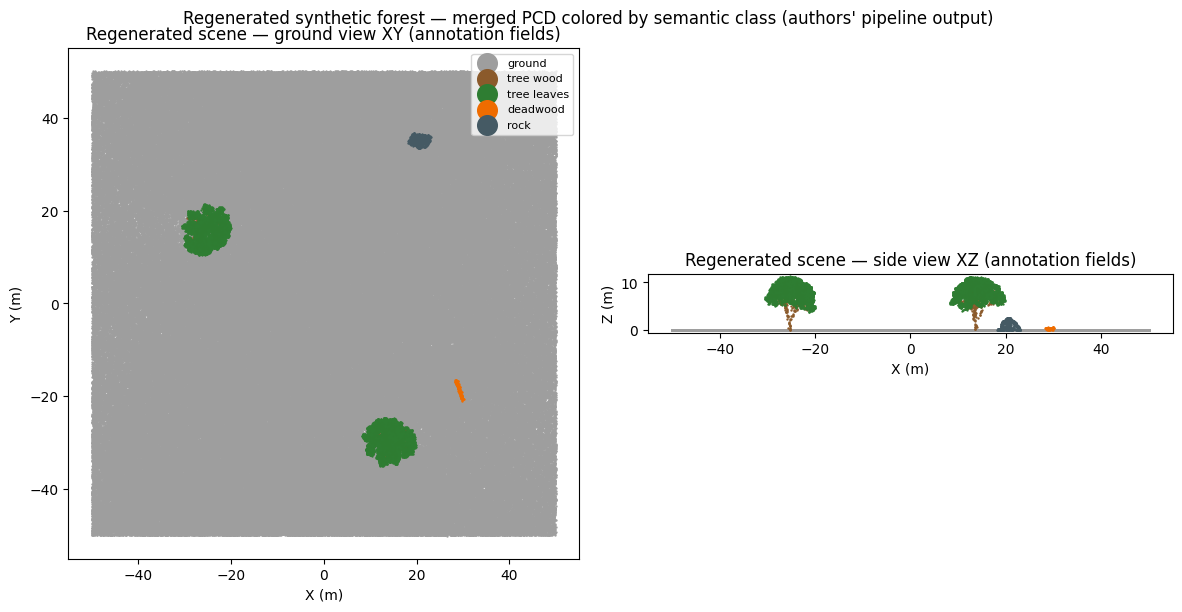

class 1 (ground): 2,911,656 points
class 2 (tree wood): 8,055 points
class 3 (tree leaves): 62,410 points
class 4 (deadwood): 890 points
class 5 (rock): 4,088 points
max instance id: 5


In [ ]:
import numpy as np, matplotlib.pyplot as plt

data = np.loadtxt(MERGED_PCD, skiprows=11)
CLASSES = {1:"ground", 2:"tree wood", 3:"tree leaves", 4:"deadwood", 5:"rock", 6:"stump", 7:"bush"}
COLORS  = {1:"#9e9e9e", 2:"#8b5a2b", 3:"#2e7d32", 4:"#ef6c00", 5:"#455a64", 6:"#bcaaa4", 7:"#7cb342"}
rng = np.random.default_rng(0)
idx = rng.choice(len(data), size=min(400_000, len(data)), replace=False)
sub_reg = data[idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, (a, b, title) in zip(axes, [(1, 2, "ground view XY"), (1, 3, "side view XZ")]):
    for cid, name in CLASSES.items():
        m = sub_reg[:, 4] == cid
        if m.any():
            ax.scatter(sub_reg[m, 1], sub_reg[m, b] if b == 3 else sub_reg[m, 2], s=0.5, c=COLORS[cid], label=name)
    ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)" if b == 2 else "Z (m)")
    ax.set_aspect("equal"); ax.set_title(f"Regenerated scene — {title} (annotation fields)")
axes[0].legend(markerscale=20, loc="upper right", fontsize=8)
fig.suptitle("Regenerated synthetic forest — merged PCD colored by semantic class (authors' pipeline output)")
plt.tight_layout(); plt.savefig("regenerated_pcd_preview.png", dpi=120); plt.show()
for cid, name in CLASSES.items():
    n_cid = int((data[:,4] == cid).sum())
    if n_cid: print(f"class {cid} ({name}): {n_cid:,} points")
print("max instance id:", int(data[:,5].max()))

## Part 2 — Verify the released dataset: `WoodLand.pcd`

The paper's released benchmark (Zenodo record **17568131**, DOI 10.5281/zenodo.17568131, **CC-BY-4.0**, published 2025-11-10) contains three 1 ha scenes. We verify the smallest, `WoodLand.pcd` (2,519,321,570 bytes, MD5 `00caae89…33622` per the record API), against the paper's claims: 38–47 M points per scene, 3302–3862 pts/m², ≈2 cm average spacing, semantic classes 1–7, and per-point instance/tree-id annotation (README "Output Format").
（第 2 部：Zenodo 公開の WoodLand.pcd をダウンロードし、論文の主張と照合します。）

### 10. Download `WoodLand.pcd` from the Zenodo record API (with checksum)

Fetches the file through the record API's returned content link (`https://zenodo.org/api/records/17568131/files/WoodLand.pcd/content`) — the documented public route — streaming to `/content`, then verifies **size and MD5** against the record metadata. Expected: ~2.5 GB in 2–5 min.
（Zenodo の記録 API の本文 URL 経由で 2.5 GB を取得し、MD5 を検証します。）

In [ ]:
import urllib.request, hashlib, time, os

URL = "https://zenodo.org/api/records/17568131/files/WoodLand.pcd/content"
MD5, SIZE = "00caae894048572939ff4bb9b2c33622", 2519321570
dest = "/content/WoodLand.pcd"
t0 = time.time()
if not os.path.exists(dest) or os.path.getsize(dest) != SIZE:
    urllib.request.urlretrieve(URL, dest)
dt = time.time() - t0
h = hashlib.md5()
with open(dest, "rb") as f:
    for chunk in iter(lambda: f.read(1 << 22), b""):
        h.update(chunk)
assert os.path.getsize(dest) == SIZE, f"size mismatch: {os.path.getsize(dest)}"
assert h.hexdigest() == MD5, f"MD5 mismatch: {h.hexdigest()}"
print(f"verified WoodLand.pcd: {SIZE:,} bytes, MD5 {h.hexdigest()}, {dt:.0f} s, {(SIZE/2**20)/max(dt,1):.0f} MiB/s")

verified WoodLand.pcd: 2,519,321,570 bytes, MD5 00caae894048572939ff4bb9b2c33622, 498 s, 5 MiB/s


### 11. Read the PCD header — schema and point count

Reads only the header lines and prints `FIELDS/SIZE/TYPE/POINTS/DATA`, verifying the 10-field annotation schema and the first-column `treeid` ordering claimed by the README, plus the exact point count for the paper's 38–47 M claim — without parsing 2.5 GB of ASCII. The first data line is also sniffed to fix the delimiter for the streaming parse.
（ヘッダのみを読み、10 項目スキーマ・点数・区切り文字を確認します。）

In [ ]:
fields, header_lines, first_data_line = {}, None, None
with open("/content/WoodLand.pcd") as f:
    for i, line in enumerate(f):
        if line.startswith("DATA"):
            fields["DATA"] = line.split()[1]; header_lines = i + 1
            first_data_line = next(f); break
        parts = line.split(maxsplit=1)
        fields[parts[0]] = parts[1].strip() if len(parts) > 1 else ""
for k in ("FIELDS", "SIZE", "TYPE", "POINTS", "DATA"):
    print(k, "=", fields.get(k))
assert fields["DATA"] == "ascii", "unexpected binary encoding"
FL = fields["FIELDS"].split()
assert FL == ['treeid','x','y','z','classification','instance','object_id','Number_Of_Returns','Return_Number','Intensity'], FL
tok = first_data_line.split()
assert len(tok) == 10, f"unexpected token count: {len(tok)}"
pcd_sep = " " if first_data_line.count(" ") == 9 else r"\s+"
n_pts = int(fields["POINTS"])
dens = n_pts / 10_000  # 100 m x 100 m plot
print(f"header lines: {header_lines} | points: {n_pts:,} | density: {dens:.0f} pts/m2 (100x100 m plot)")
print("paper claim: 38-47 M points, 3302-3862 pts/m2 ->", "PASS" if 38e6 <= n_pts <= 47e6 and 3302 <= dens <= 3862 else "CHECK")

FIELDS = treeid x y z classification instance object_id Number_Of_Returns Return_Number Intensity
SIZE = 4 4 4 4 4 4 4 4 4 4
TYPE = F F F F F F F F F F
POINTS = 38206990
DATA = ascii
header lines: 11 | points: 38,206,990 | density: 3821 pts/m2 (100x100 m plot)
paper claim: 38-47 M points, 3302-3862 pts/m2 -> PASS


### 12. Stream-parse the annotated cloud

Parses the 2.5 GB ASCII file in 5 M-row chunks (constant memory) and accumulates: semantic class distribution, `treeid` (species) values, distinct instance ids, and a deterministic ~800 k-point subsample for plotting. Expected: classes 1–7 present, ~70 tree instances plus ground/rock/deadwood, species tree-ids in 1–10 (+11 deadwood, 0 other).
（2.5 GB をチャンク処理し、クラス分布・インスタンス数・サブサンプルを取得します。）

In [ ]:
import numpy as np, pandas as pd

CHUNK = 5_000_000
n_pts = int(fields["POINTS"])
sub_every = n_pts // 800_000 + 1
cls_counts = np.zeros(8, dtype=np.int64)
tid_counts, instances, subs = {}, set(), []
crop = None   # full-resolution 10x10 m XY crop for an unbiased spacing check
for chunk in pd.read_csv("/content/WoodLand.pcd", sep=pcd_sep, header=None,
                         skiprows=header_lines, chunksize=CHUNK, dtype=np.float32, names=FL):
    u, c = np.unique(chunk["classification"].to_numpy(), return_counts=True)
    for uu, cc in zip(u, c): cls_counts[int(uu)] += int(cc)
    for tid, cnt in zip(*np.unique(chunk["treeid"].to_numpy(), return_counts=True)):
        tid_counts[int(tid)] = tid_counts.get(int(tid), 0) + int(cnt)
    instances.update(np.unique(chunk["instance"].to_numpy()).tolist())
    subs.append(chunk.iloc[::sub_every])
    if crop is None:
        cx, cy = chunk["x"].median(), chunk["y"].median()
        m = chunk["x"].between(cx - 5, cx + 5) & chunk["y"].between(cy - 5, cy + 5)
        if m.sum() >= 20_000:
            crop = chunk.loc[m, ["x", "y"]].to_numpy()
            print(f"spacing crop: 10x10 m at ({cx:.1f}, {cy:.1f}), {len(crop):,} points (full resolution)")
sub = pd.concat(subs, ignore_index=True)
del subs
print("points parsed:", int(cls_counts.sum()), "| subsample kept:", len(sub))
print("class distribution (1 ground / 2 tree wood / 3 tree leaves / 4 deadwood / 5 rock / 6 stump / 7 bush):")
for cid in range(8):
    if cls_counts[cid]: print(f"  class {cid}: {cls_counts[cid]:,}")
print("distinct instances (trees + understory + ground):", len(instances))
print("treeid (species) counts:", dict(sorted(tid_counts.items())))

spacing crop: 10x10 m at (-26.4, 14.0), 110,624 points (full resolution)


points parsed: 38206990 | subsample kept: 795982
class distribution (1 ground / 2 tree wood / 3 tree leaves / 4 deadwood / 5 rock / 6 stump / 7 bush):
  class 1: 22,434,450
  class 2: 2,547,553
  class 3: 12,562,624
  class 4: 99,928
  class 5: 162,322
  class 6: 76,594
  class 7: 323,519
distinct instances (trees + understory + ground): 125
treeid (species) counts: {0: 22996885, 1: 238440, 2: 1332825, 3: 2323842, 4: 412053, 5: 4471646, 6: 2257708, 7: 1475082, 8: 861320, 9: 769517, 10: 967744, 11: 99928}


### 13. Quantitative checks against the paper's claims

Computes the mean nearest-neighbour XY spacing **inside the full-resolution 10×10 m crop collected above** (scipy cKDTree; subsampled views would inflate this metric by their thinning factor), plus the analytic spacing implied by the measured density (√(area/points)), and assembles a claim-vs-observed table (point count, density, class coverage, tree count). The Woodland scene's ≈70 trees come from the Zenodo description.
（点密度・平均点間隔・クラス・木数を論文の主張と照合します。）

In [ ]:
from scipy.spatial import cKDTree
import numpy as np, pandas as pd

smp = crop[np.random.default_rng(1).choice(len(crop), size=min(50_000, len(crop)), replace=False)]
d, _ = cKDTree(smp).query(smp, k=2)
nn = float(d[:, 1].mean())
analytic = (10_000 / n_pts) ** 0.5
tree_instances = sub[sub["classification"].isin([2.0, 3.0])]["instance"].nunique()
checks = pd.DataFrame([
    ("points per scene", "38-47 M", f"{n_pts/1e6:.1f} M"),
    ("density (pts/m2)", "3302-3862", f"{n_pts/10_000:.0f}"),
    ("mean NN spacing (XY, full-res crop)", "~2 cm", f"{nn*100:.2f} cm"),
    ("spacing implied by density", "~2 cm", f"{analytic*100:.2f} cm"),
    ("semantic classes", "1-7 present", str(sorted(int(c) for c in np.unique(sub['classification'])))),
    ("tree instances (wood/leaf)", "Woodland ~70", str(tree_instances)),
    ("treeid values", "1-10 + 11 deadwood + 0", str(sorted(tid_counts))),
], columns=["quantity", "paper/Zenodo claim", "observed"])
print(checks.to_string(index=False))
checks.to_csv("woodland_checks.csv", index=False)

                           quantity     paper/Zenodo claim                               observed
                   points per scene                38-47 M                                 38.2 M
                   density (pts/m2)              3302-3862                                   3821
mean NN spacing (XY, full-res crop)                  ~2 cm                                2.38 cm
         spacing implied by density                  ~2 cm                                1.62 cm
                   semantic classes            1-7 present                  [1, 2, 3, 4, 5, 6, 7]
         tree instances (wood/leaf)           Woodland ~70                                     70
                      treeid values 1-10 + 11 deadwood + 0 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


### 14. Visualize the released WoodLand scene with its real annotation

Renders the deterministic subsample: ground view (XY) and side view (XZ), colored by the **actual semantic annotation stored in the released file** (not a model prediction).
（公開点群を実注釈色で可視化します。）

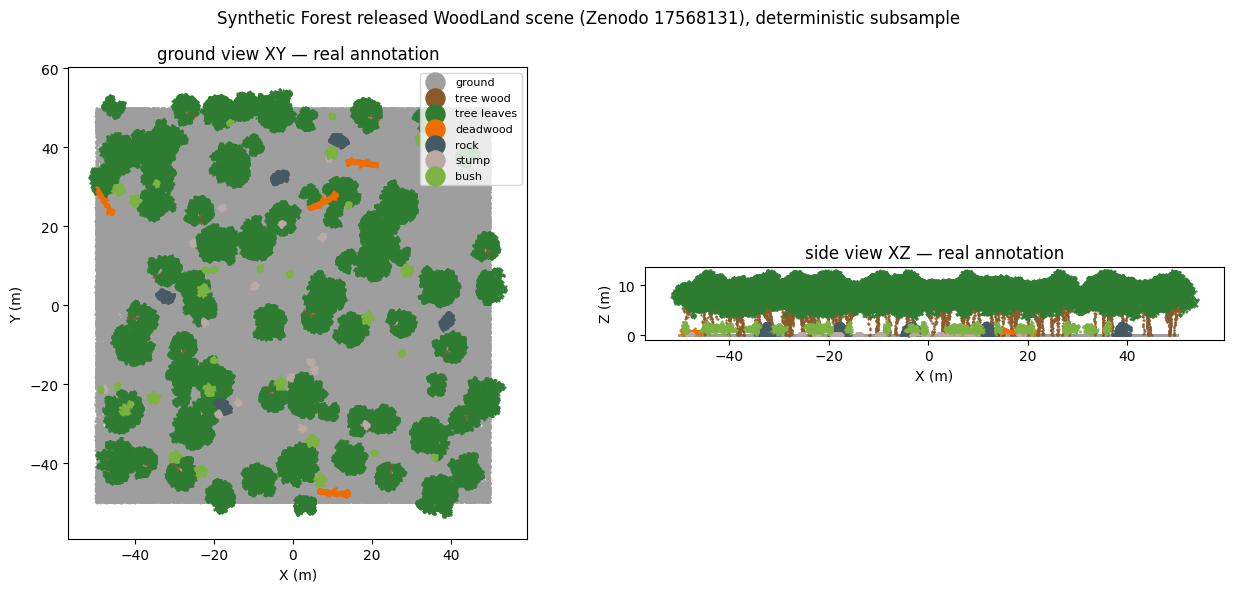

In [ ]:
import matplotlib.pyplot as plt

COLORS  = {1.0:"#9e9e9e", 2.0:"#8b5a2b", 3.0:"#2e7d32", 4.0:"#ef6c00", 5.0:"#455a64", 6.0:"#bcaaa4", 7.0:"#7cb342"}
NAMES   = {1.0:"ground", 2.0:"tree wood", 3.0:"tree leaves", 4.0:"deadwood", 5.0:"rock", 6.0:"stump", 7.0:"bush"}
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, (ya, ylab, title) in zip(axes, [("y", "Y (m)", "ground view XY — real annotation"),
                                        ("z", "Z (m)", "side view XZ — real annotation")]):
    for cid in sorted(NAMES):
        m = sub["classification"] == cid
        if m.any():
            ax.scatter(sub.loc[m, "x"], sub.loc[m, ya], s=0.3, c=COLORS[cid], label=NAMES[cid])
    ax.set_xlabel("X (m)"); ax.set_ylabel(ylab); ax.set_aspect("equal"); ax.set_title(title)
axes[0].legend(markerscale=25, loc="upper right", fontsize=8)
fig.suptitle("Synthetic Forest released WoodLand scene (Zenodo 17568131), deterministic subsample")
plt.tight_layout(); plt.savefig("woodland_annotation_preview.png", dpi=120); plt.show()

### 15. Per-tree heights and species mix

Derived from the annotation fields of the subsample: max wood-point height per tree instance, and the species (`treeid`) distribution. *Both are additional visualizations created for this notebook, not author figures.*
（木高概要と樹種分布。本ノートブックで追加作成した可視化であり、著者の図ではありません。）

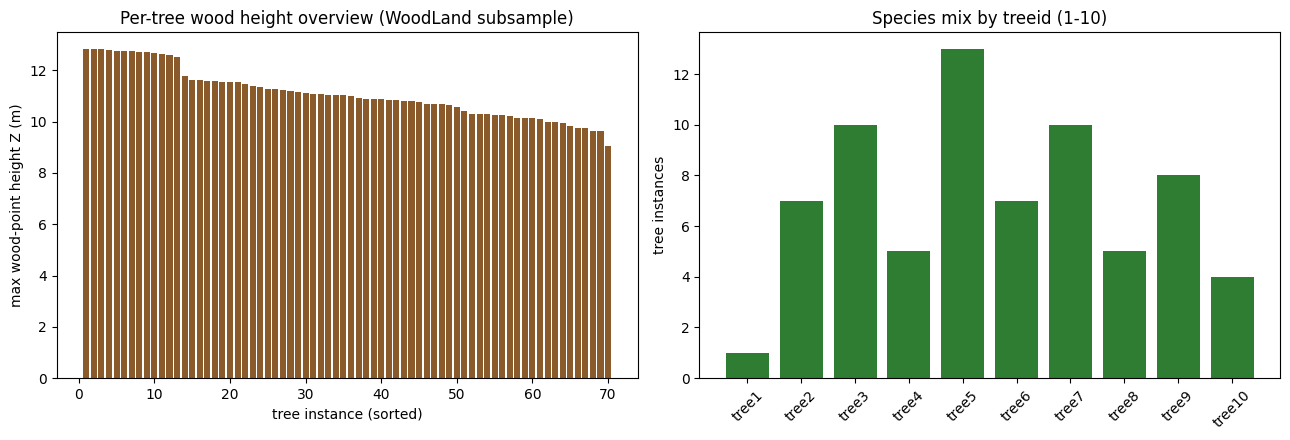

count    70.000000
mean     11.102310
std       0.965024
min       9.066800
25%      10.306800
50%      11.023400
75%      11.569475
max      12.841300


In [ ]:
import matplotlib.pyplot as plt

wood = sub[sub["classification"] == 2.0]
heights = wood.groupby("instance")["z"].max().sort_values(ascending=False)
species = wood.groupby("instance")["treeid"].agg(lambda s: int(s.mode()[0]))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(range(1, len(heights)+1), heights.values, color="#8b5a2b")
axes[0].set_xlabel("tree instance (sorted)"); axes[0].set_ylabel("max wood-point height Z (m)")
axes[0].set_title("Per-tree wood height overview (WoodLand subsample)")
sp = species.value_counts().sort_index()
axes[1].bar([f"tree{int(t)}" for t in sp.index], sp.values, color="#2e7d32")
axes[1].set_ylabel("tree instances"); axes[1].set_title("Species mix by treeid (1-10)")
plt.xticks(rotation=45)
plt.tight_layout(); plt.savefig("woodland_per_tree.png", dpi=120); plt.show()
print(heights.describe().to_string())

## 16. Interpretation, limitations, references

**What was verified here (this run, Colab CPU):**
- The authors' pipeline (scene XML → UAV survey → HELIOS++ simulation → merge) runs end-to-end and produces a 10-field annotated PCD with class ids 1–7 and the README's tree-id rules.
- The released `WoodLand.pcd` matches its recorded MD5/size and header schema, and its point count/density/spacing are consistent with the paper's claims; it contains per-point semantic classes, instance ids and species tree-ids.

**Limitations:** a 2-tree scene and a single released 1 ha scene were used — no dataset-level benchmark, no accuracy numbers, and **no wood-volume estimation** (its method is not reconstructable from the available sources; see run report). The simulation used HELIOS++ 2.2.2 instead of the authors' bundled 1.3.0 Windows build (XML-format equivalence verified; physical differences not quantified) and the survey defaults (50 kHz, 10 m/s) instead of the published 200 kHz/2 m/s settings.

**References:** paper DOI [10.5194/isprs-annals-xi-3-2026-245-2026](https://doi.org/10.5194/isprs-annals-xi-3-2026-245-2026); code [HPourdelan/Synthetic-Forest](https://github.com/HPourdelan/Synthetic-Forest) @ `66a4fa1`; data [Zenodo 17568131](https://zenodo.org/records/17568131) (CC-BY-4.0); HELIOS++ [3dgeo-heidelberg](https://github.com/3dgeo-heidelberg/helios) (GPL/LGPL).

日本語: 本ノートブックは部分再現です。パイプラインの動作と公開データの注釈スキーマ・主張値を検証しましたが、データセット全体のベンチマークや材積推定は対象外です。